Preparing PCA data practice

In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler



def load_and_inspect_digits():
  """
      요구사항:
      - sklearn.datasets.load_digits()로 데이터를 불러온다.
      - X.shape, y.shape을 출력한다 (X: (1797, 64) 예상, y: (1797,) 예상).
      - X의 전체 최소/최대 픽셀 값을 출력한다.
      - StandardScaler로 스케일링 전/후 값의 범위를 비교해서 출력한다.
  """
  digits = load_digits() #digit data
  X, y= digits.data, digits.target
  print(f"X.shape: {X.shape}")
  print(f"y.shape: {y.shape}")
  print(f"X 최소 픽셀값: {X.min()}, X 최대 픽셀값: {X.max()}") #X의 전체 최소/최대 픽셀값 출력

  scaler = StandardScaler() #StandardSclaer로 스케일링
  X_scaled = scaler.fit_transform(X)

  print(f"스케일링 전 최소 픽셀값: {X.min()}, 스케일링 전 최대 픽셀값: {X.max()}")
  print(f"스케일링 후 최소 픽셀값: {X_scaled.min()}, 스케일링 후 최대 픽셀값: {X_scaled.max()}") #스케일링 후 픽셀값 출력
load_and_inspect_digits()

X.shape: (1797, 64)
y.shape: (1797,)
X 최소 픽셀값: 0.0, X 최대 픽셀값: 16.0
스케일링 전 최소 픽셀값: 0.0, 스케일링 전 최대 픽셀값: 16.0
스케일링 후 최소 픽셀값: -3.0125999462748765, 스케일링 후 최대 픽셀값: 42.379240200834595


PCA Practice

explained_variance_ratio: 0.21594970500832789


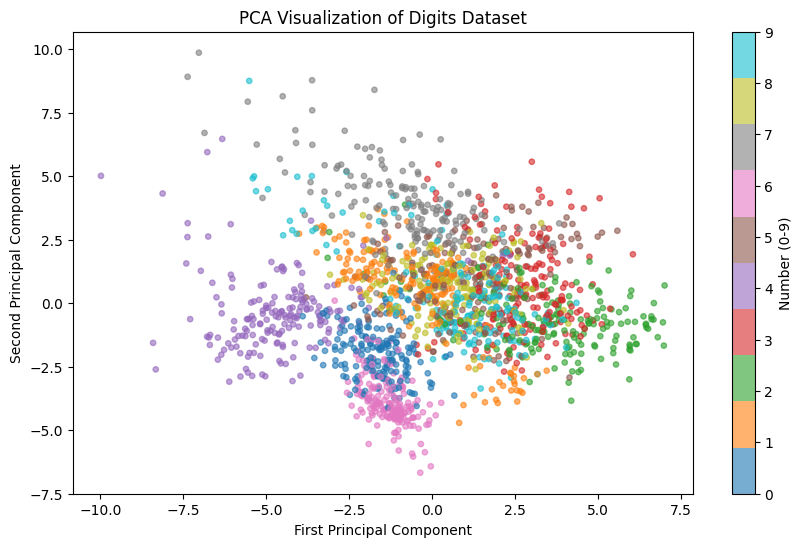

explained_variance_ratio: 0.5887375533730296


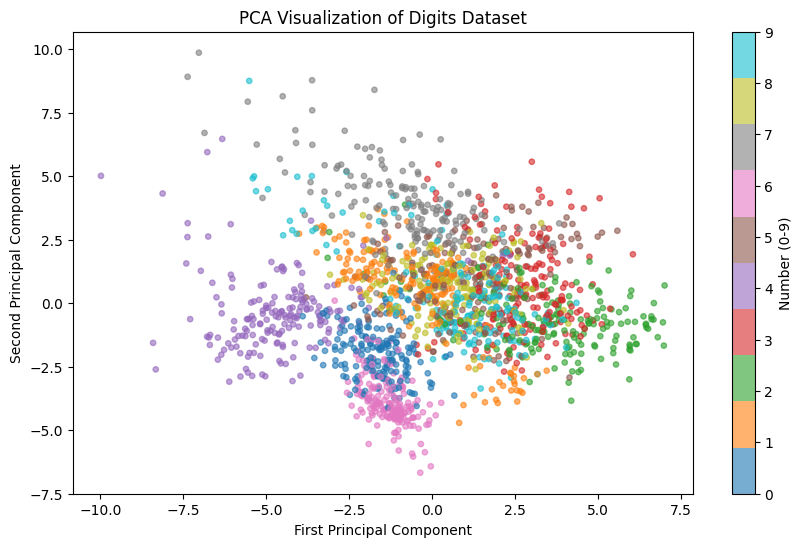

array([[-1.91421366, -0.95450157, -3.94603482, ...,  1.49606164,
         0.12491434, -0.82224561],
       [-0.58898033,  0.9246358 ,  3.92475494, ...,  0.55633553,
         1.07987725,  0.08745053],
       [-1.30203906, -0.31718883,  3.02333293, ...,  1.15616027,
         0.78560583, -1.09920591],
       ...,
       [-1.02259599, -0.14791087,  2.46997365, ...,  0.52906397,
         2.0547094 , -2.03683785],
       [-1.07605522, -0.38090625, -2.45548693, ...,  0.76332469,
         1.07747426, -0.33452721],
       [ 1.25770233, -2.22759088,  0.28362789, ..., -1.20056637,
         0.81683102, -1.82542795]])

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

digits = load_digits()
X, y = digits.data, digits.target #digit data

#Scaling with standardscaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def run_pca_pipeline(X,n_components=2):
  """
  요구사항:
  - StandardScaler로 X를 스케일링한다.
  - sklearn.decomposition.PCA(n_components)로 fit_transform한다.
  - 반환값: (X_reduced, explained_variance_ratio) 튜플.
  - 별도로 시각화 함수를 만들어, X_reduced를 라벨(y)별로 색을 다르게 해서
    scatter plot으로 그리고 'week01/pca_digits.png'로 저장한다.
  """

  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  #PCA (return : tupel(X_reduced, explained_variance_ratio))
  pca = PCA(n_components)
  X_reduced, explained_variance_ratio  = pca.fit_transform(X_scaled), pca.explained_variance_ratio_
  print(f"explained_variance_ratio: {sum(explained_variance_ratio)}")
  #Visualization
  plt.figure(figsize=(10, 6))
  scatter = plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y, cmap='tab10', alpha=0.6, s=15)
  plt.colorbar(scatter, label="Number (0-9)")
  plt.xlabel("First Principal Component")
  plt.ylabel("Second Principal Component")
  plt.title("PCA Visualization of Digits Dataset")
  plt.savefig("pca_digits.png")
  plt.show()
  return X_reduced
run_pca_pipeline(X,2)
run_pca_pipeline(X,10)


- **학습 목표**: sklearn의 PCA가 내부적으로 무엇을 계산하는지 numpy만으로 재현하고, 결과가 sklearn과 (부호를 제외하고) 일치함을 스스로 확인한다.
- **핵심 개념**: PCA = ① 공분산 행렬 계산 → ② 고유값 분해 → ③ 고유값이 큰 순서로 상위 k개 고유벡터를 골라 투영. 고유벡터의 방향은 ±로 자유롭기 때문에 sklearn 결과와 부호가 다를 수 있습니다.
- **구현 과제 (스스로 작성)**:

- Goal : Implemention of PCA with numpy, check it has same result with pca function from sklearn

explained_variance_ratio: 0.21594970500832789


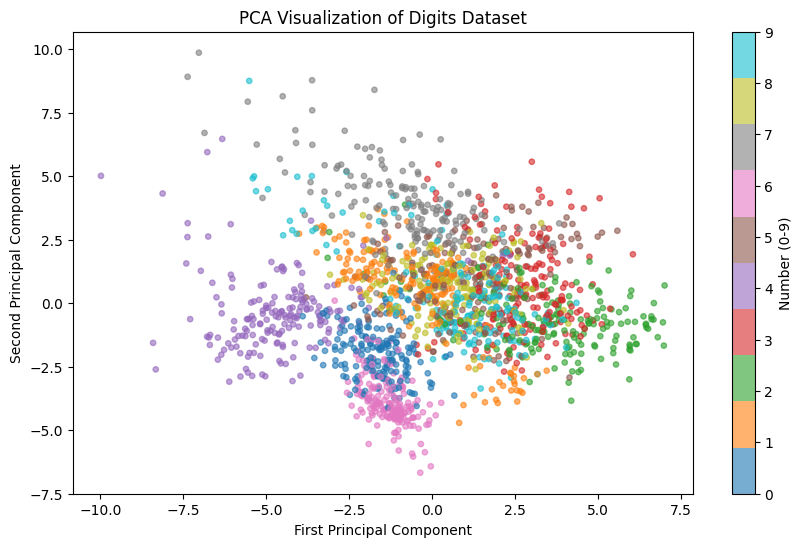

np.allclose(sklearn_result, manual) : True


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import seaborn as sns

def manual_pca_via_eigh(X_scaled, k=2):
  """
    요구사항:
    - 공분산 행렬을 (X_scaled.T @ X_scaled) / (n_samples - 1) 로 계산한다.
    - np.linalg.eigh로 고유값·고유벡터를 구하고, 고유값 내림차순으로 정렬한다.
    - 상위 k개 고유벡터로 X_scaled를 투영한 결과를 반환한다.
    - sklearn의 PCA(n_components=k) 결과와 첫 샘플을 비교해,
      np.allclose(np.abs(manual), np.abs(sklearn_result))가 True인지 확인한다.
  """
  n_samples = X_scaled.shape[0]

  # Calculate covariance matrix
  cov1 = np.cov(X_scaled, rowvar=False)
  cov2 = np.dot(X_scaled.T, X_scaled) / (n_samples - 1)
  #print(f"covariance matrix calculated by numpy.cov : \n{cov1}")
  #print(f"covariance matrix calculated by (X_scaled.T @ X_scaled) / (n_samples - 1) : \n{cov2}")
  #print(f"Cov1 == Cov2 : {np.allclose(cov1, cov2)}")
  covariance_matrix = cov1 # Use cov1 for eigenvalue decomposition

  # Perform eigendecomposition
  eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

  # Sort eigenvalues in descending order and reorder eigenvectors accordingly
  sorted_indices = np.argsort(eigenvalues)[::-1]
  sorted_eigenvalues = eigenvalues[sorted_indices]
  sorted_eigenvectors = eigenvectors[:, sorted_indices]

  # Select top k eigenvectors
  top_k_eigenvectors = sorted_eigenvectors[:, :k]

  # Project X_scaled onto the top k eigenvectors
  X_reduced_manual = X_scaled @ top_k_eigenvectors

  return X_reduced_manual

sklearn_result = run_pca_pipeline(X,2)[0]
manual = manual_pca_via_eigh(X_scaled, 2)[0]
print(f"np.allclose(sklearn_result, manual) : {np.allclose(np.abs(sklearn_result), np.abs(manual))}")

PCA를 사용하기 이전에 스케일링을 권장한다. 그 이유는 각 데이터마다 범위가 달라 그대로 PCA를 진행했을 경우 정확한 결과를 가져오지 못하기 때문이다. 그런데 digit의 경우 스케일링을 적용했을 때 PCA 이후의 값을 확인해보면 각 숫자를 구분하기 더 어려워진다.

그에 대해 찾아보니,

explained_variance_ratio: 0.28509364823699285


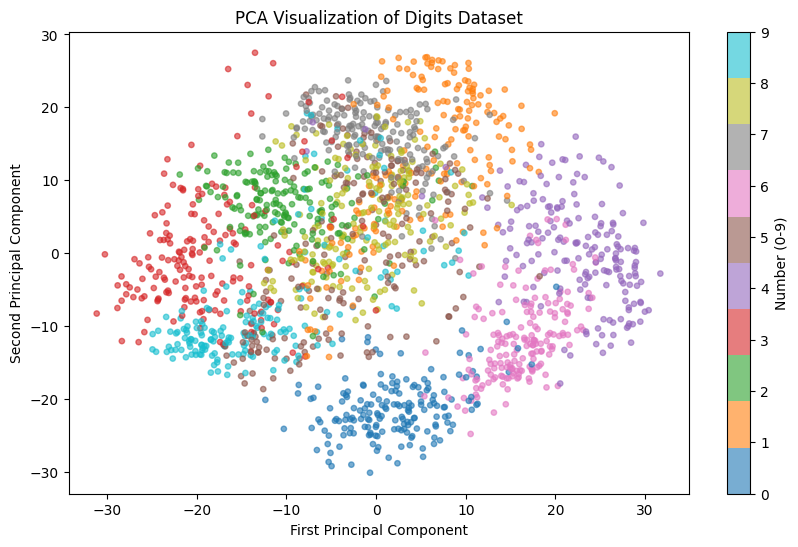

array([[ -1.25946645, -21.27488348],
       [  7.9576113 ,  20.76869896],
       [  6.99192297,   9.95598641],
       ...,
       [ 10.8012837 ,   6.96025223],
       [ -4.87210009, -12.42395362],
       [ -0.34438963,  -6.36554919]])

In [ ]:
def run_pca_pipeline_without_scaling(X,n_components=2):

  #PCA (return : tupel(X_reduced, explained_variance_ratio))
  pca = PCA(n_components)
  X_reduced, explained_variance_ratio  = pca.fit_transform(X), pca.explained_variance_ratio_
  print(f"explained_variance_ratio: {sum(explained_variance_ratio)}")
  #Visualization
  plt.figure(figsize=(10, 6))
  scatter = plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y, cmap='tab10', alpha=0.6, s=15)
  plt.colorbar(scatter, label="Number (0-9)")
  plt.xlabel("First Principal Component")
  plt.ylabel("Second Principal Component")
  plt.title("PCA Visualization of Digits Dataset")
  plt.savefig("pca_digits.png")
  plt.show()
  return X_reduced
run_pca_pipeline_without_scaling(X,2)